1. Install Library

In [2]:
!pip install pandas numpy scikit-learn nltk sastrawi wordcloud matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 10.0 MB/s eta 0:00:00


2. Import Library

In [19]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

3. Load Dataset

In [20]:
df = pd.read_csv('INA_TweetsPPKM_Labeled_Pure.csv', sep='\t', quotechar='"', doublequote=True)
df.head()

,Date,User,Tweet,sentiment
23639,2020-06-26 18:34:56+00:00,bananabluff,noelle loses a bet to akarsha and it somehow e...,1
23640,2020-06-19 15:14:07+00:00,Auqroix,they call her... weekeeshee...\n#butterflysoup...,1
23641,2020-06-18 23:45:26+00:00,Auqroix,"put out what you wanna see more of, amirite ga...",1
23642,2020-06-15 23:17:22+00:00,Auqroix,"i don't need anybody, i'm fine here on my own\...",1
23643,2020-05-06 04:34:13+00:00,nindiiayudya,"Selamat Siang sahabat online, nih aku sedikit ...",0


In [ ]:
with open('INA_TweetsPPKM_Labeled_Pure.csv', 'r') as f:
    for i, line in enumerate(f):
        if i < 10:  # Read the first 10 lines to inspect
            print(f"Line {i+1}: {line.strip()}")
        else:
            break

Line 1: Date	User	Tweet	sentiment
Line 2: 2022-03-31 14:32:04+00:00	pikobar_jabar	Ketahui informasi pembagian #PPKM di wilayah Jabar berdasarkan level 3, 2 dan 1 di #PikoData https://t.co/o2RnI7eDue	1
Line 3: 2022-03-31 09:26:00+00:00	inewsdotid	"Tempat Ibadah di Wilayah PPKM Level 1 Boleh Berkapasitas 100 Persen. Baca Selengkapnya di https://t.co/JfIG6nIimN
Line 4: #Ramadhan #PPKM #inews https://t.co/ky1G5xYLQB"	1
Line 5: 2022-03-31 05:02:34+00:00	vdvc_talk	"Juru bicara Satgas Covid-19, Wiku Adisasmito menjelaskan bahwa bukber diperbolehkan dengan menjaga jarak, tidak mengobrol, serta tidak lupa cuci tangan sebelum makan.
Line 6: 
Line 7: Begini kira-kira gambaran bukber tanpa ngobrol. Bagaimana tanggapan sobat VDVC?
Line 8: #VDVCNews #Viral #PPKM #Bukber https://t.co/SWuFmfaIYN"	1
Line 9: 2022-03-30 14:23:10+00:00	pikobar_jabar	Ketahui informasi pembagian #PPKM di wilayah Jabar berdasarkan level 4, 3, dan 2 di #PikoData https://t.co/16XU0AcfPW	1
Line 10: 2022-03-30 11:28:57+00:00	tvO

4. Data Cleaning

In [21]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_tweet'] = df['Tweet'].apply(clean_text)

5. Stopword Removal + Stemming

In [22]:
stop_words = set(stopwords.words('indonesian'))

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess_text(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [stemmer.stem(word) for word in words]
    return ' '.join(words)

df['processed_tweet'] = df['clean_tweet'].apply(preprocess_text)

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['processed_tweet'])
y = df['sentiment']

6. TF-IDF

In [23]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['processed_tweet'])
y = df['sentiment']

7. Split Data Training & Testing

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8. Naive Bayes Model

In [25]:
model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

9. Evaluasi Model

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8156058363290336
              precision    recall  f1-score   support

           0       0.87      0.05      0.10       377
           1       0.82      0.98      0.89      3569
           2       0.78      0.42      0.55       783

    accuracy                           0.82      4729
   macro avg       0.82      0.48      0.51      4729
weighted avg       0.82      0.82      0.77      4729



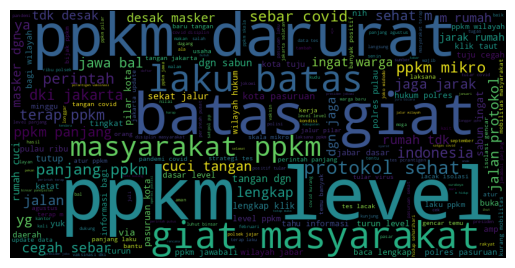

In [27]:
positive_text = ' '.join(df[df['sentiment']==1]['processed_tweet'])

wordcloud = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

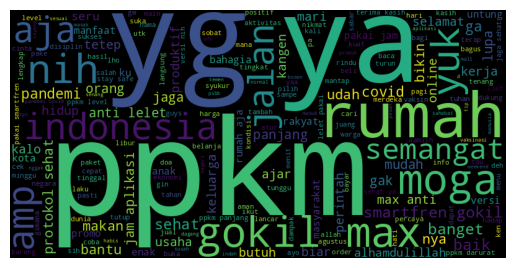

In [28]:
negative_text = ' '.join(df[df['sentiment']==0]['processed_tweet'])

wordcloud = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

Grafik distribusi

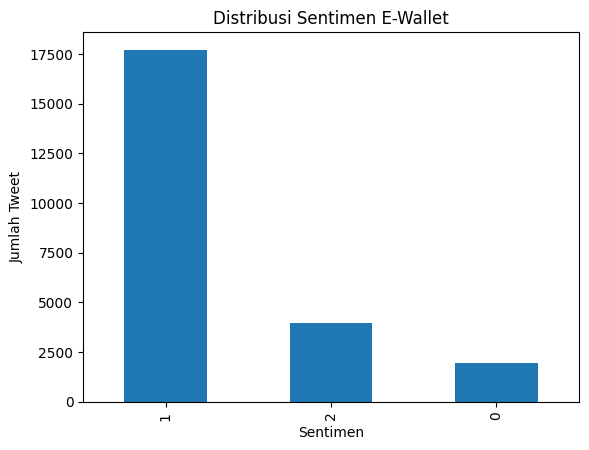

In [29]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Distribusi Sentimen E-Wallet')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Tweet')
plt.show()

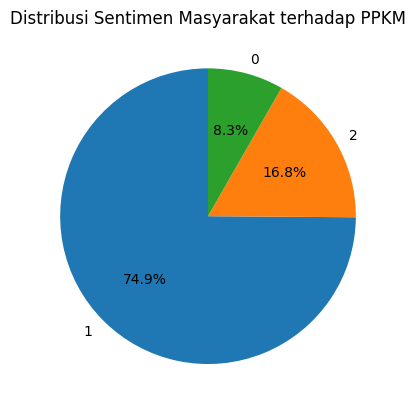

In [30]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentiment'].value_counts()

plt.figure()
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribusi Sentimen Masyarakat terhadap PPKM')
plt.show()